# Datacamp 'Intermediate PyTorch' Chapter 3
This chapter covers sequence models using an electricity consumption dataset for the example.  Capture the code from the course as well as investigating other approaches e.g. statsmodels tsa etc.

In [1]:
from startup import np, pd, Path, smf, plt, sns
from zipfile import ZipFile

In [22]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
from torchmetrics import Accuracy, Precision, Recall, F1Score, MeanSquaredError

In [3]:
# For CNN
from torchvision.datasets import ImageFolder
from torchvision import transforms

In [4]:
from ydf import RandomForestLearner

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import pacf, acf

In [8]:
data_dir = Path.home() / 'Work' / 'Data' / 'datacamp_intermediate_pytorch'
data_file = data_dir / 'electricity_consump.zip'
zip_file = ZipFile(data_file)
dfs = {
    csv_file.filename.split('/')[1].rstrip('.csv').split('_')[1]: pd.read_csv(zip_file.open(csv_file.filename),
                                                                              encoding='ISO-8859-1', parse_dates=['timestamp'])
    for csv_file in zip_file.infolist() if csv_file.filename.endswith('csv') and not csv_file.filename.startswith('__')
}

<Axes: xlabel='timestamp'>

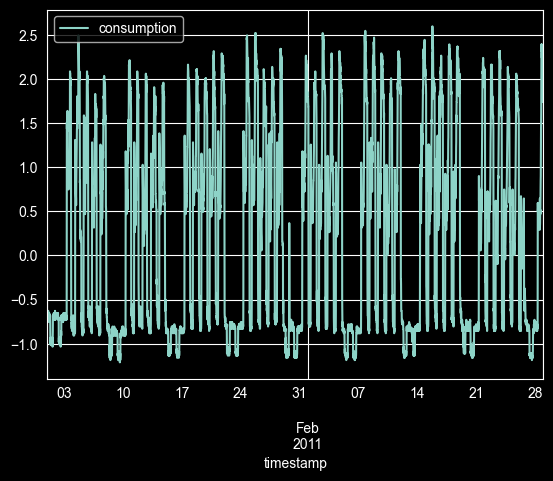

In [14]:
# Sample of data
df_s = dfs['train'].set_index('timestamp').loc['2011-01':'2011-02']
df_s.plot()

In [19]:
# sns.barplot(pacf(df_s.values))

In [24]:
# dfs['train'].describe()

In [23]:
# dfs['test'].describe()

Creating sequences

In [27]:
def create_sequence(df, seq_length):
    # Code from video
    xs, ys = [], []
    for i in range(len(df) - seq_length):
        xs.append(df.iloc[i:(i + seq_length), 1].values)
        ys.append(df.iloc[i + seq_length, 1])
    return np.array(xs), np.array(ys)

In [28]:
seq_length = 24*4*1 # Hours x Samples Per Hour x Days
X_train, y_train = create_sequence(dfs['train'], seq_length)
print(X_train.shape, y_train.shape)

(105119, 96) (105119,)


In [29]:
dataset_train = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

In [41]:
# Alternative: write dataset class
class ElectricityDataset(Dataset):
    def __init__(self, df, seq_length):
        self.df = df
        self.seq_length = seq_length

    def __len__(self):
        return len(self.df) - self.seq_length

    def __getitem__(self, idx):
        x = self.df.iloc[idx:seq_length+idx, 1].values
        y = self.df.iloc[seq_length+idx, 1]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [42]:
alt_dataset_train = ElectricityDataset(dfs['train'], seq_length)

In [45]:
np.allclose(alt_dataset_train[1][0], dataset_train[1][0])

True

In [46]:
np.allclose(alt_dataset_train[1][1], dataset_train[1][1])

True

In [47]:
class RnnNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Define RNN layer
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # Initialize first hidden state with zeros
        h0 = torch.zeros(2, x.size(0), 32)
        # Pass x and h0 through recurrent layer
        out, _ = self.rnn(x, h0)
        # Pass recurrent layer's last output through linear layer
        out = self.fc(out[:, -1, :])
        return out

In [48]:
class LstmNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Define lstm layer
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        # Initialize long-term memory
        c0 = torch.zeros(2, x.size(0), 32)
        # Pass all inputs to lstm layer
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
class GruNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Define GRU layer
        self.gru = nn.GRU(
            input_size=1,
            hidden_size=32,
            num_layers=2,
            batch_first=True,
        )
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        h0 = torch.zeros(2, x.size(0), 32)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [56]:
dataloader_train = DataLoader(
    dataset_train, batch_size=32, shuffle=True
)
dataloader_test = DataLoader(
    ElectricityDataset(dfs['test'], 24*4), batch_size=32, shuffle=True
)

In [57]:
net = LstmNet()
# Set up MSE loss
criterion = nn.MSELoss()
optimizer = optim.Adam(
  net.parameters(), lr=0.0001
)

for epoch in range(3):
    for seqs, labels in dataloader_train:
        # Reshape model inputs
        seqs = seqs.view(-1, 96, 1)
        # Get model outputs
        outputs = net(seqs)
        # Compute loss
        loss = criterion(outputs.squeeze(), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.1091737374663353
Epoch 2, Loss: 0.02594393864274025
Epoch 3, Loss: 0.08742978423833847


In [58]:
# Define MSE metric
mse = MeanSquaredError()

net.eval()
with torch.no_grad():
    for seqs, labels in dataloader_test:
        seqs = seqs.view(-1, 96, 1)
        # Pass seqs to net and squeeze the result
        outputs = net(seqs).squeeze()
        mse(outputs, labels)

# Compute final metric value
test_mse = mse.compute()
print(f"Test MSE: {test_mse}")

Test MSE: 0.03945719078183174
